This notebook will analyze the Financial News and Stock Price Integration Dataset (FNSPID). Specifically, this work will try to detect patterns in financial news publishing, characteristics of headlines, publisher behavior, and financial topics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

In [3]:
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   Unnamed: 0  1407328 non-null  int64 
 1   headline    1407328 non-null  object
 2   url         1407328 non-null  object
 3   publisher   1407328 non-null  object
 4   date        1407328 non-null  object
 5   stock       1407328 non-null  object
dtypes: int64(1), object(5)
memory usage: 64.4+ MB


(1407328, 6)

In [4]:
df.isnull().sum()
df.duplicated().sum()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [5]:
df["headline_length"] = df["headline"].astype(str).apply(len)

In [6]:
df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

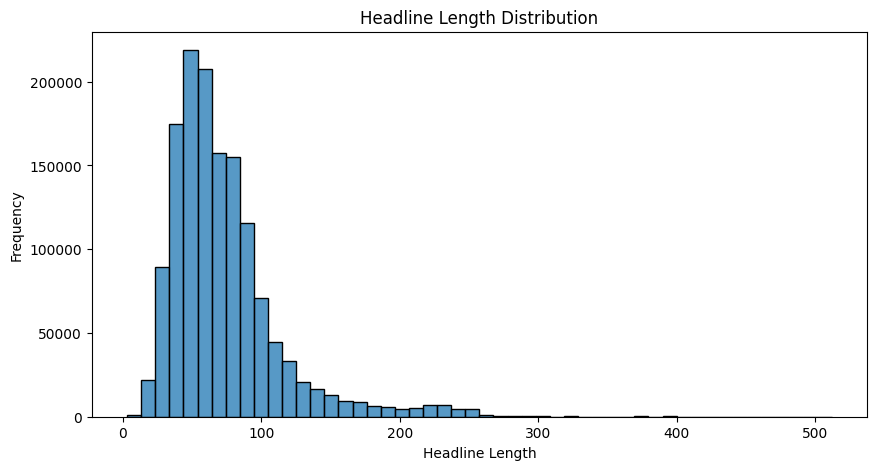

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df["headline_length"], bins=50)
plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")
plt.show()

The pattern suggests that the majority of headlines are short and concise, which is usually characteristic of financial news reports since the headline contains important market information.

In [8]:
publisher_counts = df["publisher"].value_counts().head(10)
publisher_counts

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

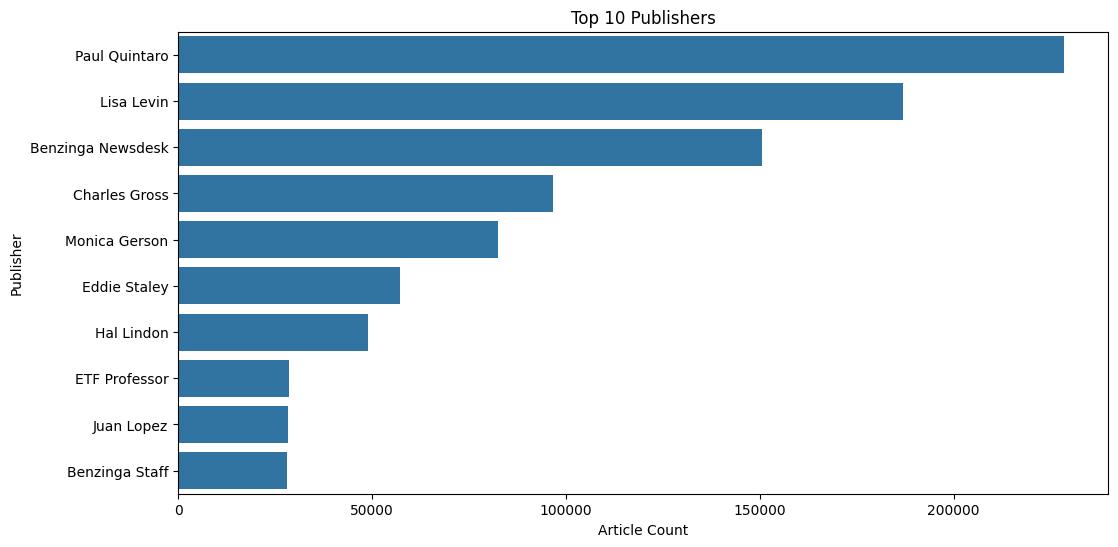

In [9]:
plt.figure(figsize=(12,6))
sns.barplot(x=publisher_counts.values,
            y=publisher_counts.index)

plt.title("Top 10 Publishers")
plt.xlabel("Article Count")
plt.ylabel("Publisher")
plt.show()

A small number of publishers contribute a disproportionately large volume of articles, suggesting that financial news distribution is dominated by a few major players.

In [10]:
df["publisher_domain"] = df["publisher"].str.extract(r'@(.+)')

In [11]:
df["publisher_domain"].value_counts().head(10)

publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

In [12]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [13]:
daily_news = df.groupby(df["date"].dt.date).size()

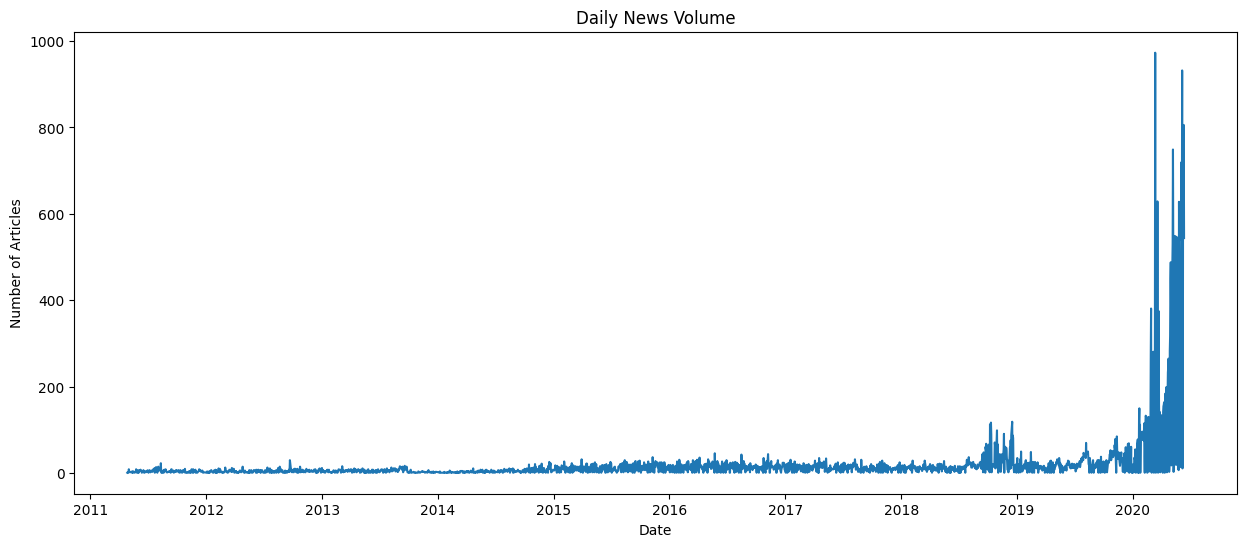

In [14]:
plt.figure(figsize=(15,6))
daily_news.plot()

plt.title("Daily News Volume")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()


It is evident from the graph that there are several peaks in the number of publications, possibly due to earnings seasons or other reasons.

In [15]:
df["hour"] = df["date"].dt.hour

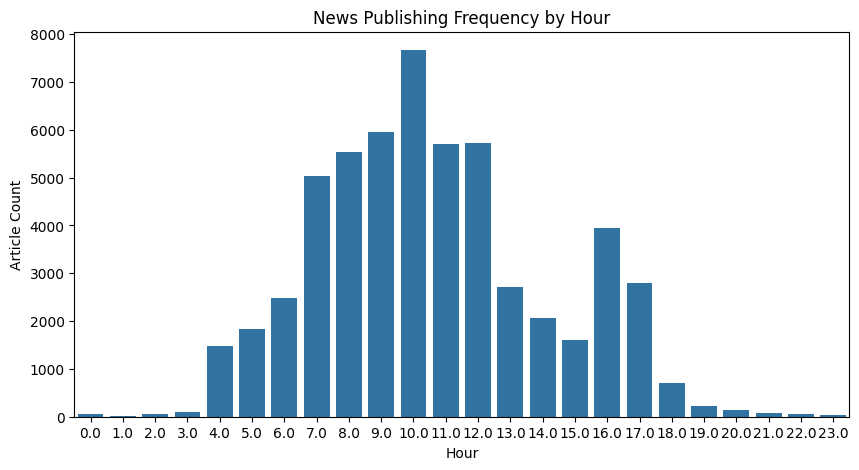

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(x=df["hour"])

plt.title("News Publishing Frequency by Hour")
plt.xlabel("Hour")
plt.ylabel("Article Count")
plt.show()

In [17]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=20
)

X = tfidf.fit_transform(df["headline"].astype(str))

keywords = tfidf.get_feature_names_out()

keywords

array(['announces', 'benzinga', 'buy', 'downgrades', 'earnings', 'eps',
       'est', 'market', 'mid', 'price', 'pt', 'raises', 'reports',
       'sales', 'shares', 'stocks', 'trading', 'update', 'vs', 'week'],
      dtype=object)

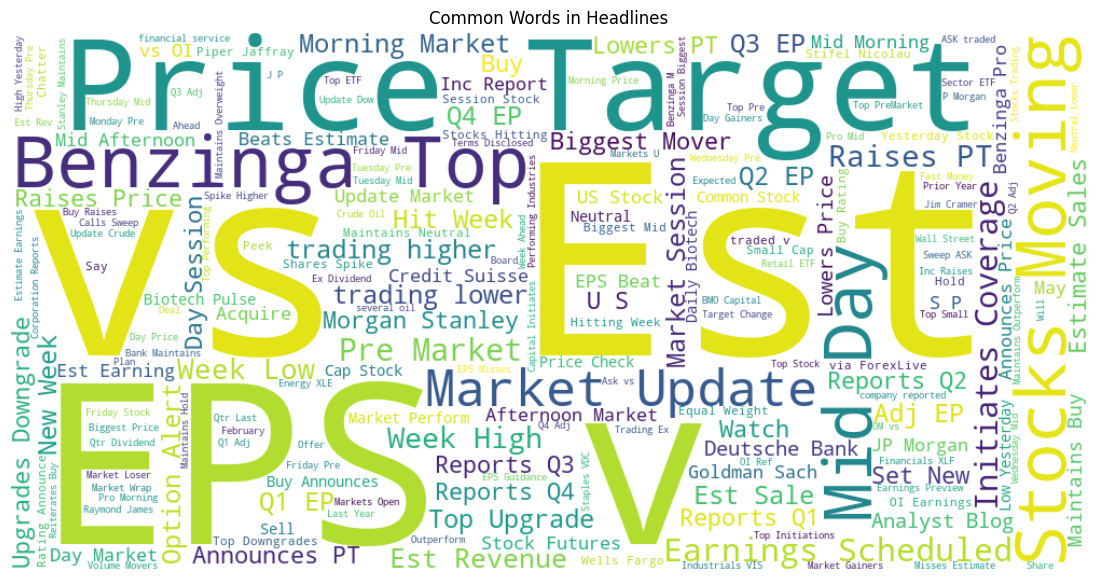

In [18]:
text = " ".join(df["headline"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Headlines")
plt.show()

## Topic and Theme Discussion

The text analysis reveals several recurring financial themes across news headlines.

Common themes include:

- earnings reports and quarterly performance updates
- analyst upgrades and price target revisions
- mergers and acquisitions
- FDA approvals and regulatory announcements
- stock market momentum and trading activity

The frequent appearance of terms related to earnings, ratings, and acquisitions suggests that financial news coverage is strongly focused on events that may influence short-term market sentiment and investor decision-making.

## Key Insights

1. A small number of publishers contribute a disproportionately high number of articles.

2. News publishing activity shows noticeable spikes around specific dates, suggesting reaction to major market events or earnings seasons.

3. Financial headlines heavily emphasize earnings, ratings, acquisitions, and price targets.

4. Publishing frequency peaks during market-active hours.